# OTUS CMS DoubleElectron plotting notebook — paper-style ratio plots

This notebook loads a trained OTUS model checkpoint and makes validation plots in the same style as the `ppzeePaperPlots` reference notebook:

- top panel: overlaid histograms,
- bottom panel: prediction / truth ratio,
- single-ratio plots for z-space `z` vs `x -> z`,
- double-ratio plots for x-space `x` vs `x -> z -> x` and `z -> x`.

It keeps the same input paths as the earlier plotting notebook. It does **not** train.


In [1]:
# =====================
# 0. Imports and paths
# =====================

%matplotlib inline

import os
# Helpful on Windows if OpenMP gets loaded twice by numpy/torch/matplotlib.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
import json
import math
import warnings
from pathlib import Path

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

import re

try:
    from scipy.stats import ks_2samp
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    print("scipy not found: KS statistics will be skipped.")

# -------------------------
# Find the OTUS repo root
# -------------------------
# This works if the notebook is placed anywhere inside the OTUS repo.
# If auto-detection fails, manually set REPO_ROOT below.

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start] + list(start.parents):
        if (p / "utilityFunctions").exists():
            return p
    return start

REPO_ROOT = find_repo_root()
UTILITY_DIR = REPO_ROOT / "utilityFunctions"
if str(UTILITY_DIR) not in sys.path:
    sys.path.insert(0, str(UTILITY_DIR))

print("REPO_ROOT:", REPO_ROOT)
print("UTILITY_DIR:", UTILITY_DIR)
print("Using torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

REPO_ROOT: C:\Users\AhrixMarin\Desktop\otus
UTILITY_DIR: C:\Users\AhrixMarin\Desktop\otus\utilityFunctions
Using torch: 2.12.0+cu126
CUDA available: True
DEVICE: cuda


## 1. User settings

This version uses the **real CMS detector-level x** from the ROOT file:

```text
OTUS/experiments/cms_zpeak/data/Run2012B_DoubleElectron.root
```

and uses the MG5 prior z from:

```text
OTUS/experiments/cms_doubleelectron/cms_dyee_mg5_8tev_fiducial_70_110.hdf5
```

Put this notebook in:

```text
OTUS/experiments/cms_doubleelectron/
```

The important rule is:

```text
CMS x  = reconstructed electron pairs from the ROOT file
MG5 z  = theory-level four-vectors from the HDF5 file
```

The notebook will no longer accidentally load `FDL/zData` as both x and z.


In [2]:
# =====================
# 1. User settings
# =====================

# This cell is written for the repo layout in your screenshot:
#
# OTUS/
#   data/
#   utilityFunctions/
#   experiments/
#     cms_doubleelectron/
#       saves/
#         cms_doubleelectron_mg5_dyee_XL_lambda0.7/
#           model_full.pt
#           model_state_dict.pkl
#           results_test.npz
#       cms_dyee_mg5_8tev_fiducial_70_110.hdf5
#       cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5
#       cms_doubleelectron_plot.ipynb
#     cms_zpeak/
#       data/
#         Run2012B_DoubleElectron.root

# -------- Locate folders --------
# Works whether you launch Jupyter from OTUS/ or from OTUS/experiments/cms_doubleelectron/.
EXP_DIR = REPO_ROOT / "experiments" / "cms_doubleelectron"
if not EXP_DIR.exists():
    EXP_DIR = Path.cwd().resolve()

CMS_ZPEAK_DIR = REPO_ROOT / "experiments" / "cms_zpeak"

SAVE_DIR = EXP_DIR / "saves" / "cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction"

TAG = "QED0_massloss"
OUTDIR = SAVE_DIR / "plots" / TAG
OUTDIR.mkdir(parents=True, exist_ok=True)

# -------- Model checkpoint --------
MODEL_PATH = SAVE_DIR / "model_full.pt"
# If this fails on your machine, switch to:
# MODEL_PATH = SAVE_DIR / "model_state_dict.pkl"

# -------- Real CMS x file --------
# This is the detector-level CMS DoubleElectron sample.
CMS_ROOT_FILE = CMS_ZPEAK_DIR / "data" / "Run2012B_DoubleElectron.root"
CMS_X_FILE = CMS_ROOT_FILE

# -------- MG5 prior z file --------
# Main QED0 / DYee prior used for the current run.
DATA_FILE = EXP_DIR / "cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5"

MG5_Z_FILE = DATA_FILE

# Optional: saved outputs from the training notebook.
RESULTS_TEST_NPZ = SAVE_DIR / "results_test.npz"

# Optional: if your training notebook saved x_train/x_val/z_train/z_val to npz, set this path.
TRAINING_ARRAYS_NPZ = None

# -------- ROOT reading settings --------
# Usually leave these as None. If the automatic branch finder fails, inspect the printed branch list
# and set these names manually.
CMS_TREE_NAME = None
CMS_ELECTRON_PT_BRANCH = None
CMS_ELECTRON_ETA_BRANCH = None
CMS_ELECTRON_PHI_BRANCH = None
CMS_ELECTRON_E_BRANCH = None
CMS_ELECTRON_CHARGE_BRANCH = None

# Selection used to build x from the ROOT file.
# Keep this consistent with the training notebook.
CMS_ELECTRON_PT_MIN = 20.0
CMS_ELECTRON_ABS_ETA_MAX = 2.5
CMS_REQUIRE_OPPOSITE_CHARGE = True
CMS_ROOT_MASS_MIN = 70.0
CMS_ROOT_MASS_MAX = 110.0

# -------- HDF5 dataset key candidates for MG5 z --------
# IMPORTANT: do not use these for CMS x when CMS_X_FILE is ROOT.
MG5_Z_KEYS = [
    "z_val", "z_test", "zData", "z_data", "FDL/zData", "FDL/z_data",
    "events", "mg5_z", "MG5/zData"
]

# Keep this only for fallback if you intentionally set CMS_X_FILE to an HDF5/NPZ file later.
CMS_X_KEYS = [
    "x_val", "x_test", "xData", "x_data", "FDL/xData", "FDL/x_data",
    "events", "selected_events", "cms_x", "CMS/xData"
]

# -------- Train/eval split used only if TRAINING_ARRAYS_NPZ is None --------
TRAIN_SIZE_X = None
VAL_SIZE_X = None
TRAIN_SIZE_Z = None
VAL_SIZE_Z = None

# -------- Model architecture: must match training notebook --------
COND_NOISE = True
NUM_HIDDEN_LAYERS = 2
DIM_PER_HIDDEN_LAYER = 256
RAW_IO = True
STOCH_ENC = True
STOCH_DEC = True
SIGMA_FUN = "softplus"
ACTIVATION = torch.nn.ReLU

# -------- Plot settings --------
SEED = 0
MAX_X_EVENTS = 80000
MAX_Z_EVENTS = 80000
BATCH_SIZE = 20000
MZ_REF = 91.1880

# Paper-style invariant-mass plots use 1 GeV bins, matching ppzeePaperPlots.
MASS_BINS = np.arange(70, 111, 1.0)
PT_BINS = np.linspace(0, 100, 101)
COMPONENT_BINS_Z = 80
COMPONENT_BINS_X = 80

# True  -> normalize each histogram to area = 1, compare shapes only.
# False -> show raw event counts, closer to the original OTUS paper plots.
NORMALIZE_DENSITY = True

print("EXP_DIR:", EXP_DIR)
print("CMS_ZPEAK_DIR:", CMS_ZPEAK_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("CMS_X_FILE:", CMS_X_FILE)
print("MG5_Z_FILE:", MG5_Z_FILE)
print("OUTDIR:", OUTDIR)


EXP_DIR: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron
CMS_ZPEAK_DIR: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak
SAVE_DIR: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction
MODEL_PATH: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\model_full.pt
CMS_X_FILE: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root
MG5_Z_FILE: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5
OUTDIR: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss


In [ ]:
# ======================================
# 2. Generic array-loading helper tools
# ======================================

def require_path(path, label="file"):
    path = Path(path)
    if not path.exists():
        print(f"Cannot find {label}: {path.resolve()}")
        print("\nNearby HDF5/NPZ/PT/PTH files under current directory:")
        for pattern in ["*.hdf5", "*.h5", "*.npz", "*.pt", "*.pth"]:
            matches = sorted(Path.cwd().rglob(pattern))[:50]
            if matches:
                print(f"\n{pattern}:")
                for m in matches[:20]:
                    print("  ", m)
        raise FileNotFoundError(path)
    return path


def list_hdf5_tree(path):
    path = Path(path)
    print(f"HDF5 tree for {path}:")
    with h5py.File(path, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  DATASET {name}: shape={obj.shape}, dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"  GROUP   {name}")
        f.visititems(visitor)


def load_hdf5_array(path, candidate_keys, expected_cols=8, label="array"):
    path = require_path(path, label)
    with h5py.File(path, "r") as f:
        # First try candidate keys.
        for key in candidate_keys:
            if key in f and isinstance(f[key], h5py.Dataset):
                arr = np.asarray(f[key])
                print(f"Loaded {label} from {path}:{key}, shape={arr.shape}")
                return arr
        # Then recursively search for a 2D dataset with expected number of columns.
        found = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                try:
                    shape = obj.shape
                    if len(shape) == 2 and shape[1] == expected_cols:
                        found.append(name)
                except Exception:
                    pass
        f.visititems(visitor)
        if len(found) == 1:
            arr = np.asarray(f[found[0]])
            print(f"Loaded {label} from {path}:{found[0]}, shape={arr.shape}")
            return arr
        if len(found) > 1:
            print("Multiple possible datasets found:", found)
            print("Set the correct key in CMS_X_KEYS or MG5_Z_KEYS.")
            raise KeyError("Ambiguous HDF5 dataset")
        print("No matching dataset found. Here is the file tree:")
        list_hdf5_tree(path)
        raise KeyError(f"Could not find {label} in {path}")


def as_float32(a):
    return np.asarray(a, dtype=np.float32)


def finite_8d(a, name="array"):
    a = np.asarray(a)
    if a.ndim != 2 or a.shape[1] != 8:
        raise ValueError(f"{name} must have shape (N, 8). Got {a.shape}")
    mask = np.isfinite(a).all(axis=1)
    if mask.sum() < len(a):
        print(f"Dropped {len(a) - mask.sum()} non-finite rows from {name}")
    return a[mask]


def split_train_val(a, train_size=None, val_size=None):
    if train_size is None:
        train = a
        if val_size is None:
            val = a
        else:
            val = a[:val_size]
    else:
        train = a[:train_size]
        if val_size is None:
            val = a[train_size:]
        else:
            val = a[train_size:train_size + val_size]
    return train, val


def random_subset(a, n, seed=0):
    a = np.asarray(a)
    if n is None or len(a) <= n:
        return a
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(a), size=n, replace=False)
    return a[idx]


# ======================================
# 2.1 ROOT loader for real CMS x
# ======================================

def _canon_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def _import_uproot_awkward():
    try:
        import uproot
        import awkward as ak
        return uproot, ak
    except Exception as e:
        raise ImportError(
            "To load the real CMS ROOT file, install uproot and awkward in this environment.\n"
            "Try:\n"
            "    pip install uproot awkward\n"
            "or inside conda:\n"
            "    conda install -c conda-forge uproot awkward\n"
            f"Original import error: {repr(e)}"
        )


def list_root_trees_and_branches(path, max_branches=80):
    uproot, ak = _import_uproot_awkward()
    path = require_path(path, "CMS ROOT file")
    f = uproot.open(path)
    print(f"ROOT file: {path}")
    print("Top-level keys:", list(f.keys()))
    for key in f.keys():
        obj = f[key]
        if hasattr(obj, "keys") and hasattr(obj, "num_entries"):
            branches = list(obj.keys())
            print(f"\nTTree candidate: {key}, entries={obj.num_entries}, nbranches={len(branches)}")
            for b in branches[:max_branches]:
                print("  ", b)
            if len(branches) > max_branches:
                print(f"  ... {len(branches) - max_branches} more branches")


def get_first_ttree(path, preferred_name=None):
    uproot, ak = _import_uproot_awkward()
    path = require_path(path, "CMS ROOT file")
    f = uproot.open(path)

    if preferred_name is not None:
        # Accept either "Events" or "Events;1"
        if preferred_name in f:
            return f[preferred_name], preferred_name
        for key in f.keys():
            if key.split(";")[0] == preferred_name:
                return f[key], key
        raise KeyError(f"CMS_TREE_NAME={preferred_name!r} not found. Available keys: {list(f.keys())}")

    for key in f.keys():
        obj = f[key]
        if hasattr(obj, "keys") and hasattr(obj, "num_entries"):
            return obj, key

    raise KeyError(f"No TTree found in {path}. Available keys: {list(f.keys())}")


def find_branch(tree, manual_name, candidates, term_sets, label):
    """Find a branch by exact candidates first, then by required terms."""
    branches = list(tree.keys())
    canon_to_branch = {_canon_name(b): b for b in branches}

    if manual_name is not None:
        if manual_name in branches:
            return manual_name
        cmanual = _canon_name(manual_name)
        if cmanual in canon_to_branch:
            return canon_to_branch[cmanual]
        raise KeyError(f"Manual {label} branch {manual_name!r} not found. Available branches include: {branches[:80]}")

    for cand in candidates:
        cc = _canon_name(cand)
        if cc in canon_to_branch:
            return canon_to_branch[cc]

    # Try broad term matching. Example: ["electron", "pt"] matches Electron_pt or Electron.PT.
    for terms in term_sets:
        cterms = [_canon_name(t) for t in terms]
        matches = []
        for b in branches:
            cb = _canon_name(b)
            if all(t in cb for t in cterms):
                matches.append(b)
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            # Prefer shorter names; often the clean branch is the shortest.
            matches_sorted = sorted(matches, key=lambda x: (len(str(x)), str(x)))
            print(f"Multiple possible {label} branches found for terms {terms}: {matches_sorted[:20]}")
            print(f"Using: {matches_sorted[0]}")
            return matches_sorted[0]

    nearby = [b for b in branches if ("ele" in _canon_name(b) or "electron" in _canon_name(b))][:80]
    print(f"Could not auto-detect {label} branch.")
    print("Electron-like branches:")
    for b in nearby:
        print("  ", b)
    raise KeyError(f"Could not find {label} branch")


def _mass_from_components(px1, py1, pz1, E1, px2, py2, pz2, E2, eps=0.0):
    m2 = (E1 + E2)**2 - (px1 + px2)**2 - (py1 + py2)**2 - (pz1 + pz2)**2
    return np.sqrt(np.maximum(m2, eps))


def load_cms_doubleelectron_root(
    root_path,
    tree_name=None,
    pt_min=20.0,
    abs_eta_max=2.5,
    mass_window=(70.0, 110.0),
    require_opposite_charge=True,
    max_events=None,
):
    """
    Load real CMS DoubleElectron ROOT data and return x with columns:
        [e- px, e- py, e- pz, e- E, e+ px, e+ py, e+ pz, e+ E]

    The function:
      1. finds electron pt/eta/phi/E/charge branches,
      2. applies pT and eta cuts,
      3. builds opposite-sign electron pairs,
      4. keeps pairs in the mass window,
      5. picks the pair closest to mZ if multiple pairs exist.
    """
    uproot, ak = _import_uproot_awkward()
    root_path = require_path(root_path, "CMS ROOT file")
    tree, tree_key = get_first_ttree(root_path, preferred_name=tree_name)
    print(f"Using ROOT tree: {tree_key}")
    print(f"Tree entries: {tree.num_entries}")

    # Branch auto-detection. Override these in the settings cell if needed.
    pt_b = find_branch(
        tree, CMS_ELECTRON_PT_BRANCH,
        ["Electron_pt", "Electron.PT", "ElectronPt", "electron_pt", "ele_pt", "pt"],
        [["electron", "pt"], ["ele", "pt"]],
        "electron pt",
    )
    eta_b = find_branch(
        tree, CMS_ELECTRON_ETA_BRANCH,
        ["Electron_eta", "Electron.Eta", "ElectronEta", "electron_eta", "ele_eta", "eta"],
        [["electron", "eta"], ["ele", "eta"]],
        "electron eta",
    )
    phi_b = find_branch(
        tree, CMS_ELECTRON_PHI_BRANCH,
        ["Electron_phi", "Electron.Phi", "ElectronPhi", "electron_phi", "ele_phi", "phi"],
        [["electron", "phi"], ["ele", "phi"]],
        "electron phi",
    )

    # Energy branch is strongly preferred. If absent, use massless E = pT*cosh(eta).
    try:
        E_b = find_branch(
            tree, CMS_ELECTRON_E_BRANCH,
            ["Electron_energy", "Electron.Energy", "Electron_E", "Electron.E", "ElectronE", "electron_energy", "electron_e", "ele_E", "energy", "E"],
            [["electron", "energy"], ["ele", "energy"]],
            "electron energy",
        )
    except Exception as e:
        E_b = None
        print("Could not find electron energy branch. Using massless approximation E = pT*cosh(eta).")
        print("Energy-branch detection error:", repr(e))

    charge_b = find_branch(
        tree, CMS_ELECTRON_CHARGE_BRANCH,
        ["Electron_charge", "Electron.Charge", "ElectronCharge", "electron_charge", "ele_charge", "charge"],
        [["electron", "charge"], ["ele", "charge"]],
        "electron charge",
    )

    branches = [pt_b, eta_b, phi_b, charge_b] + ([] if E_b is None else [E_b])
    print("ROOT branches used:")
    print("  pt:     ", pt_b)
    print("  eta:    ", eta_b)
    print("  phi:    ", phi_b)
    print("  energy: ", E_b if E_b is not None else "massless approximation")
    print("  charge: ", charge_b)

    arrays = tree.arrays(branches, library="ak", entry_stop=max_events)
    pt = arrays[pt_b]
    eta = arrays[eta_b]
    phi = arrays[phi_b]
    charge = arrays[charge_b]
    E = arrays[E_b] if E_b is not None else pt * np.cosh(eta)

    # Apply per-electron kinematic cuts.
    good_ele = (pt >= pt_min) & (abs(eta) <= abs_eta_max)
    pt = pt[good_ele]
    eta = eta[good_ele]
    phi = phi[good_ele]
    charge = charge[good_ele]
    E = E[good_ele]

    # Sort electrons by pT inside each event for stable behavior.
    order = ak.argsort(pt, axis=1, ascending=False)
    pt = pt[order]
    eta = eta[order]
    phi = phi[order]
    charge = charge[order]
    E = E[order]

    electrons = ak.zip({
        "pt": pt,
        "eta": eta,
        "phi": phi,
        "E": E,
        "charge": charge,
    })

    pairs = ak.combinations(electrons, 2, fields=["a", "b"])

    if require_opposite_charge:
        pairs = pairs[(pairs.a.charge * pairs.b.charge) < 0]

    px1 = pairs.a.pt * np.cos(pairs.a.phi)
    py1 = pairs.a.pt * np.sin(pairs.a.phi)
    pz1 = pairs.a.pt * np.sinh(pairs.a.eta)
    E1 = pairs.a.E

    px2 = pairs.b.pt * np.cos(pairs.b.phi)
    py2 = pairs.b.pt * np.sin(pairs.b.phi)
    pz2 = pairs.b.pt * np.sinh(pairs.b.eta)
    E2 = pairs.b.E

    mass = _mass_from_components(px1, py1, pz1, E1, px2, py2, pz2, E2)
    mlo, mhi = mass_window
    in_window = (mass >= mlo) & (mass <= mhi)
    pairs = pairs[in_window]
    mass = mass[in_window]

    # Pick pair closest to mZ per event.
    best = ak.argmin(abs(mass - MZ_REF), axis=1, keepdims=True)
    best_pairs = pairs[best]
    best_pairs = ak.flatten(best_pairs, axis=1)

    if len(best_pairs) == 0:
        raise RuntimeError(
            "No CMS ee candidates survived the ROOT selection. "
            "Check branch names, pT/eta cuts, opposite-charge requirement, and mass window."
        )

    # Convert selected pair to numpy arrays.
    a_pt = ak.to_numpy(best_pairs.a.pt)
    a_eta = ak.to_numpy(best_pairs.a.eta)
    a_phi = ak.to_numpy(best_pairs.a.phi)
    a_E = ak.to_numpy(best_pairs.a.E)
    a_q = ak.to_numpy(best_pairs.a.charge)

    b_pt = ak.to_numpy(best_pairs.b.pt)
    b_eta = ak.to_numpy(best_pairs.b.eta)
    b_phi = ak.to_numpy(best_pairs.b.phi)
    b_E = ak.to_numpy(best_pairs.b.E)
    b_q = ak.to_numpy(best_pairs.b.charge)

    a_px = a_pt * np.cos(a_phi)
    a_py = a_pt * np.sin(a_phi)
    a_pz = a_pt * np.sinh(a_eta)

    b_px = b_pt * np.cos(b_phi)
    b_py = b_pt * np.sin(b_phi)
    b_pz = b_pt * np.sinh(b_eta)

    # OTUS convention: [e- four-vector, e+ four-vector].
    a_is_minus = (a_q < 0)

    em_px = np.where(a_is_minus, a_px, b_px)
    em_py = np.where(a_is_minus, a_py, b_py)
    em_pz = np.where(a_is_minus, a_pz, b_pz)
    em_E  = np.where(a_is_minus, a_E,  b_E)

    ep_px = np.where(a_is_minus, b_px, a_px)
    ep_py = np.where(a_is_minus, b_py, a_py)
    ep_pz = np.where(a_is_minus, b_pz, a_pz)
    ep_E  = np.where(a_is_minus, b_E,  a_E)

    x = np.stack([em_px, em_py, em_pz, em_E, ep_px, ep_py, ep_pz, ep_E], axis=1).astype(np.float32)
    x = finite_8d(x, "CMS x from ROOT")

    m = _mass_from_components(x[:,0], x[:,1], x[:,2], x[:,3], x[:,4], x[:,5], x[:,6], x[:,7])
    print("Loaded real CMS x from ROOT:", x.shape)
    print("CMS x mass mean/std:", float(np.mean(m)), "/", float(np.std(m)))
    print("CMS x mass quantiles [1%,5%,50%,95%,99%]:", np.quantile(m, [0.01, 0.05, 0.50, 0.95, 0.99]))

    return x

def paper_ratio_residual_plot_double(
    truth,
    pred1,
    pred2,
    bins,
    xlabel,
    title,
    filename,
    truth_label=TRUTH_LABEL_X,
    pred1_label=PRED_LABEL_X_RECO,
    pred2_label=PRED_LABEL_X_GEN,
    pred1_style=ENCDEC_STYLE,
    pred2_style=DEC_STYLE,
    xlim=None,
    ratio_ylim=(0.5, 1.5),
    residual_ylim=(-0.05, 0.05),
    target_rel=0.01,
    density=None,
    annotate_w=True,
):
    """
    Paper-style plot with three panels:

    top:      data vs OTUS
    middle:   OTUS / data
    bottom:  (OTUS - data) / data

    The bottom panel directly shows the relative error.
    target_rel=0.01 means ±1%.
    """

    if density is None:
        density = NORMALIZE_DENSITY

    truth = finite_values(truth)
    pred1 = finite_values(pred1)
    pred2 = finite_values(pred2)

    centers, h_truth, c_truth, widths = hist_for_plot(truth, bins, density=density)
    _, h_pred1, c_pred1, _ = hist_for_plot(pred1, bins, density=density)
    _, h_pred2, c_pred2, _ = hist_for_plot(pred2, bins, density=density)

    ratio1, err1 = ratio_and_error(h_pred1, h_truth, c_pred1, c_truth)
    ratio2, err2 = ratio_and_error(h_pred2, h_truth, c_pred2, c_truth)

    # This is the requested panel:
    #     (OTUS - data) / data
    # Since ratio = OTUS / data, residual = ratio - 1.
    residual1 = ratio1 - 1.0
    residual2 = ratio2 - 1.0

    fig = plt.figure(figsize=(7.0, 7.4))
    gs = fig.add_gridspec(
        3, 1,
        height_ratios=[3.0, 1.05, 1.05],
        hspace=0.05,
    )

    ax = fig.add_subplot(gs[0])
    rax = fig.add_subplot(gs[1], sharex=ax)
    dax = fig.add_subplot(gs[2], sharex=ax)

    # ---------------------
    # Top panel: histograms
    # ---------------------
    draw_hist_step(ax, centers, h_truth, truth_label, TRUTH_STYLE)
    draw_hist_step(ax, centers, h_pred1, pred1_label, pred1_style)
    draw_hist_step(ax, centers, h_pred2, pred2_label, pred2_style)

    if annotate_w:
        w1 = w2_1d_np(truth, pred1)
        w2 = w2_1d_np(truth, pred2)

        ax.text(
            0.97, 0.92,
            fr"$W_2^2(x,\tilde{{x}}) = {w1:.3e}$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            color=pred1_style.get("color", "black"),
            fontsize=9,
        )

        ax.text(
            0.97, 0.84,
            fr"$W_2^2(x,\tilde{{x}}^\prime) = {w2:.3e}$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            color=pred2_style.get("color", "black"),
            fontsize=9,
        )

    ax.set_ylabel(r"Normalized density" if density else "Counts")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.18)

    # ---------------------
    # Middle panel: ratio
    # ---------------------
    rax.errorbar(
        centers,
        ratio1,
        yerr=err1,
        fmt="o",
        markersize=3.5,
        color=pred1_style.get("color", "black"),
        ecolor=pred1_style.get("color", "black"),
        elinewidth=1.0,
        capsize=0,
        label=pred1_label,
    )

    rax.errorbar(
        centers,
        ratio2,
        yerr=err2,
        fmt="s",
        markersize=3.0,
        color=pred2_style.get("color", "black"),
        ecolor=pred2_style.get("color", "black"),
        elinewidth=1.0,
        capsize=0,
        label=pred2_label,
    )

    rax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0)
    rax.set_ylabel("OTUS\ndata")
    rax.set_ylim(*ratio_ylim)
    rax.grid(alpha=0.18)

    # ---------------------------------------
    # Bottom panel: relative residual / error
    # ---------------------------------------
    dax.axhspan(
        -target_rel,
        target_rel,
        color="gray",
        alpha=0.18,
        label=fr"$\pm {100 * target_rel:.0f}\%$ target",
    )

    dax.errorbar(
        centers,
        residual1,
        yerr=err1,
        fmt="o",
        markersize=3.5,
        color=pred1_style.get("color", "black"),
        ecolor=pred1_style.get("color", "black"),
        elinewidth=1.0,
        capsize=0,
        label=pred1_label,
    )

    dax.errorbar(
        centers,
        residual2,
        yerr=err2,
        fmt="s",
        markersize=3.0,
        color=pred2_style.get("color", "black"),
        ecolor=pred2_style.get("color", "black"),
        elinewidth=1.0,
        capsize=0,
        label=pred2_label,
    )

    dax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    dax.set_ylabel(r"$\frac{\mathrm{OTUS}-\mathrm{data}}{\mathrm{data}}$")
    dax.set_xlabel(xlabel)
    dax.set_ylim(*residual_ylim)
    dax.grid(alpha=0.18)
    dax.legend(loc="best", fontsize=8)

    if xlim is not None:
        ax.set_xlim(*xlim)

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(rax.get_xticklabels(), visible=False)

    plt.tight_layout()

    path = OUTDIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

    # ---------------------
    # Simple numerical check
    # ---------------------
    valid1 = np.isfinite(residual1)
    valid2 = np.isfinite(residual2)

    if valid1.any():
        print(
            f"x -> z -> x residual: "
            f"mean |rel err| = {np.nanmean(np.abs(residual1[valid1])):.4g}, "
            f"max |rel err| = {np.nanmax(np.abs(residual1[valid1])):.4g}, "
            f"bins within ±{100 * target_rel:.0f}% = "
            f"{100 * np.mean(np.abs(residual1[valid1]) < target_rel):.1f}%"
        )

    if valid2.any():
        print(
            f"z -> x residual: "
            f"mean |rel err| = {np.nanmean(np.abs(residual2[valid2])):.4g}, "
            f"max |rel err| = {np.nanmax(np.abs(residual2[valid2])):.4g}, "
            f"bins within ±{100 * target_rel:.0f}% = "
            f"{100 * np.mean(np.abs(residual2[valid2]) < target_rel):.1f}%"
        )

    return fig, (ax, rax, dax), {
        "centers": centers,
        "truth": h_truth,
        "pred1": h_pred1,
        "pred2": h_pred2,
        "ratio1": ratio1,
        "ratio2": ratio2,
        "residual1": residual1,
        "residual2": residual2,
        "ratio_err1": err1,
        "ratio_err2": err2,
    }


In [4]:
# =====================
# 3. Load x and z data
# =====================

if TRAINING_ARRAYS_NPZ is not None:
    TRAINING_ARRAYS_NPZ = require_path(TRAINING_ARRAYS_NPZ, "TRAINING_ARRAYS_NPZ")
    arrays = np.load(TRAINING_ARRAYS_NPZ)
    print("NPZ keys:", arrays.files)
    x_train = as_float32(arrays["x_train"])
    z_train = as_float32(arrays["z_train"])
    x_val = as_float32(arrays["x_val"] if "x_val" in arrays else arrays["x_train"])
    z_val = as_float32(arrays["z_val"] if "z_val" in arrays else arrays["z_train"])
    x_all = np.concatenate([x_train, x_val], axis=0)
    z_all = np.concatenate([z_train, z_val], axis=0)
else:
    # x-space truth: real CMS DoubleElectron ROOT file
    if str(CMS_X_FILE).lower().endswith(".root"):
        x_all = as_float32(load_cms_doubleelectron_root(
            CMS_X_FILE,
            tree_name=CMS_TREE_NAME,
            pt_min=CMS_ELECTRON_PT_MIN,
            abs_eta_max=CMS_ELECTRON_ABS_ETA_MAX,
            mass_window=(CMS_ROOT_MASS_MIN, CMS_ROOT_MASS_MAX),
            require_opposite_charge=CMS_REQUIRE_OPPOSITE_CHARGE,
        ))
    else:
        # HDF5 fallback only. This should not be used for the real CMS x run.
        x_all = as_float32(load_hdf5_array(CMS_X_FILE, CMS_X_KEYS, expected_cols=8, label="CMS x"))

    # z-space prior: MG5 HDF5 file
    z_all = as_float32(load_hdf5_array(MG5_Z_FILE, MG5_Z_KEYS, expected_cols=8, label="MG5 z"))

    x_all = finite_8d(x_all, "CMS x")
    z_all = finite_8d(z_all, "MG5 z")
    x_train, x_val = split_train_val(x_all, TRAIN_SIZE_X, VAL_SIZE_X)
    z_train, z_val = split_train_val(z_all, TRAIN_SIZE_Z, VAL_SIZE_Z)

x_dim = x_all.shape[1]
z_dim = z_all.shape[1]
assert x_dim == 8 and z_dim == 8

x_train_mean, x_train_std = np.mean(x_train, axis=0), np.std(x_train, axis=0)
z_train_mean, z_train_std = np.mean(z_train, axis=0), np.std(z_train, axis=0)

# Protect against zero std.
x_train_std = np.where(x_train_std == 0, 1.0, x_train_std)
z_train_std = np.where(z_train_std == 0, 1.0, z_train_std)

print("x_all shape:", x_all.shape)
print("z_all shape:", z_all.shape)
print("x_train shape:", x_train.shape, "x_val shape:", x_val.shape)
print("z_train shape:", z_train.shape, "z_val shape:", z_val.shape)
print("x_train_mean:", x_train_mean)
print("z_train_mean:", z_train_mean)

# Safety check: x and z should not be numerically identical.
# If this triggers, the notebook is still loading the wrong x source.
if x_all.shape == z_all.shape:
    same_sample = np.allclose(x_all[:min(1000, len(x_all))], z_all[:min(1000, len(z_all))])
    if same_sample:
        raise RuntimeError(
            "CMS x and MG5 z appear identical. That means x was probably loaded from zData. "
            "Check CMS_X_FILE and the ROOT loader."
        )


Using ROOT tree: Events;1
Tree entries: 21474287
Could not auto-detect electron energy branch.
Electron-like branches:
   nElectron
   Electron_pt
   Electron_eta
   Electron_phi
   Electron_mass
   Electron_charge
   Electron_pfRelIso03_all
   Electron_dxy
   Electron_dxyErr
   Electron_dz
   Electron_dzErr
Could not find electron energy branch. Using massless approximation E = pT*cosh(eta).
Energy-branch detection error: KeyError('Could not find electron energy branch')
ROOT branches used:
  pt:      Electron_pt
  eta:     Electron_eta
  phi:     Electron_phi
  energy:  massless approximation
  charge:  Electron_charge
Dropped 19361678 non-finite rows from CMS x from ROOT
Loaded real CMS x from ROOT: (2112609, 8)
CMS x mass mean/std: 90.12882995605469 / 6.579697132110596
CMS x mass quantiles [1%,5%,50%,95%,99%]: [ 71.53991943  76.8787674   90.86180115 100.32919617 107.31388611]
Loaded MG5 z from C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\cms_dyee_mg5_8tev_dy1j_pt

In [5]:
# ============================
# 4. Physics helper functions
# ============================

def inv_mass_ee(a, eps=0.0):
    """Invariant mass from [e- px,py,pz,E, e+ px,py,pz,E]."""
    a = np.asarray(a)
    px = a[:, 0] + a[:, 4]
    py = a[:, 1] + a[:, 5]
    pz = a[:, 2] + a[:, 6]
    E  = a[:, 3] + a[:, 7]
    m2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.maximum(m2, eps))


def pt_ee(a):
    a = np.asarray(a)
    px = a[:, 0] + a[:, 4]
    py = a[:, 1] + a[:, 5]
    return np.sqrt(px**2 + py**2)


def rapidity_ee(a, eps=1e-12):
    a = np.asarray(a)
    pz = a[:, 2] + a[:, 6]
    E  = a[:, 3] + a[:, 7]
    return 0.5 * np.log(np.maximum((E + pz) / np.maximum(E - pz, eps), eps))


def w2_1d_np(a, b):
    """Equal-weight 1D W2^2-like number used only for quick plot annotations."""
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    n = min(len(a), len(b))
    if n == 0:
        return np.nan
    a = np.sort(a)[:n]
    b = np.sort(b)[:n]
    return np.mean((a - b)**2)


def hist_norm_counts(values, bins):
    counts, edges = np.histogram(values, bins=bins)
    counts = counts.astype(float)
    total = counts.sum()
    if total > 0:
        counts /= total
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


def safe_ratio(num, den):
    ratio = np.full_like(num, np.nan, dtype=float)
    mask = den > 0
    ratio[mask] = num[mask] / den[mask]
    return ratio


def maybe_ks(a, b):
    if not HAS_SCIPY:
        return np.nan, np.nan
    out = ks_2samp(np.asarray(a), np.asarray(b))
    return float(out.statistic), float(out.pvalue)

# Quick sanity check
for name, arr in [("CMS x", x_all), ("MG5 z", z_all)]:
    m = inv_mass_ee(arr[:min(len(arr), 100000)])
    print(f"{name}: m_ee mean/std on sample = {m.mean():.4f} / {m.std():.4f} GeV")

CMS x: m_ee mean/std on sample = 90.1607 / 6.5755 GeV
MG5 z: m_ee mean/std on sample = 91.1187 / 4.0109 GeV


## 4.1 Paper-style ratio plotting helpers

The reference notebook uses `ratioPlotSingle` for z-space comparisons and `ratioPlotDouble` for x-space comparisons. This notebook implements a lightweight version directly here so we can use normalized-density histograms while keeping the same visual logic.


In [6]:
# ======================================
# 4.1 Paper-style ratio plotting helpers
# ======================================

# These colors/styles mimic the OTUS paper plots:
# truth = black; encoder = cyan; encoder-decoder = green; decoder = purple.
TRUTH_STYLE = dict(color="black", linewidth=1.8, linestyle="-")
ENC_STYLE = dict(color="deepskyblue", linewidth=1.8, linestyle="--")
ENCDEC_STYLE = dict(color="forestgreen", linewidth=1.8, linestyle=":")
DEC_STYLE = dict(color="darkviolet", linewidth=1.8, linestyle="--")

TRUTH_LABEL_Z = "Ground truth: z"
PRED_LABEL_Z = r"OTUS encoder: $x \rightarrow \tilde{z}$"
TRUTH_LABEL_X = "Ground truth: x"
PRED_LABEL_X_RECO = r"OTUS encoder-decoder: $x \rightarrow \tilde{z} \rightarrow \tilde{x}$"
PRED_LABEL_X_GEN = r"OTUS decoder: $z \rightarrow \tilde{x}^{\prime}$"


def finite_values(a):
    a = np.asarray(a).reshape(-1)
    return a[np.isfinite(a)]


def hist_for_plot(values, bins, density=True):
    """Return bin centers, plot heights, raw counts, and bin widths."""
    values = finite_values(values)
    counts, edges = np.histogram(values, bins=bins)
    counts = counts.astype(float)
    widths = np.diff(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    if density:
        total = counts.sum()
        if total > 0:
            heights = counts / (total * widths)
        else:
            heights = np.zeros_like(counts)
    else:
        heights = counts.copy()

    return centers, heights, counts, widths


def ratio_and_error(pred_heights, truth_heights, pred_counts, truth_counts):
    """Ratio = prediction/truth. Error is approximate Poisson ratio error."""
    pred_heights = np.asarray(pred_heights, dtype=float)
    truth_heights = np.asarray(truth_heights, dtype=float)
    pred_counts = np.asarray(pred_counts, dtype=float)
    truth_counts = np.asarray(truth_counts, dtype=float)

    ratio = np.full_like(pred_heights, np.nan, dtype=float)
    err = np.full_like(pred_heights, np.nan, dtype=float)

    mask = (truth_heights > 0) & (truth_counts > 0) & np.isfinite(truth_heights)
    ratio[mask] = pred_heights[mask] / truth_heights[mask]

    # Only draw errors where both numerator and denominator have entries.
    emask = mask & (pred_counts > 0)
    err[emask] = ratio[emask] * np.sqrt(1.0 / pred_counts[emask] + 1.0 / truth_counts[emask])
    return ratio, err


def draw_hist_step(ax, centers, heights, label, style):
    ax.step(centers, heights, where="mid", label=label, **style)


def paper_ratio_plot_single(
    truth,
    pred,
    bins,
    xlabel,
    title,
    filename,
    truth_label=TRUTH_LABEL_Z,
    pred_label=PRED_LABEL_Z,
    pred_style=ENC_STYLE,
    xlim=None,
    ratio_ylim=(0.5, 1.5),
    density=None,
    annotate_w=True,
):
    """Paper-style plot: truth vs one prediction with prediction/truth ratio."""
    if density is None:
        density = NORMALIZE_DENSITY

    truth = finite_values(truth)
    pred = finite_values(pred)

    centers, h_truth, c_truth, widths = hist_for_plot(truth, bins, density=density)
    _, h_pred, c_pred, _ = hist_for_plot(pred, bins, density=density)
    ratio, rerr = ratio_and_error(h_pred, h_truth, c_pred, c_truth)

    fig = plt.figure(figsize=(7.0, 6.0))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.0, 1.05], hspace=0.04)
    ax = fig.add_subplot(gs[0])
    rax = fig.add_subplot(gs[1], sharex=ax)

    draw_hist_step(ax, centers, h_truth, truth_label, TRUTH_STYLE)
    draw_hist_step(ax, centers, h_pred, pred_label, pred_style)

    if annotate_w:
        w = w2_1d_np(truth, pred)
        ax.text(0.97, 0.92, fr"$W_2^2 = {w:.3e}$", transform=ax.transAxes,
                ha="right", va="top", color=pred_style.get("color", "black"), fontsize=10)

    ax.set_ylabel(r"Normalized density" if density else "Counts")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=10)
    ax.grid(alpha=0.18)

    rax.errorbar(centers, ratio, yerr=rerr, fmt="o", markersize=3.5,
                 color=pred_style.get("color", "black"), ecolor=pred_style.get("color", "black"),
                 elinewidth=1.0, capsize=0)
    rax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0)
    rax.set_ylabel("Ratio\nto truth")
    rax.set_xlabel(xlabel)
    rax.set_ylim(*ratio_ylim)
    rax.grid(alpha=0.18)

    if xlim is not None:
        ax.set_xlim(*xlim)

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.tight_layout()

    path = OUTDIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
    return fig, (ax, rax), {"centers": centers, "truth": h_truth, "pred": h_pred, "ratio": ratio, "ratio_err": rerr}


def paper_ratio_plot_double(
    truth,
    pred1,
    pred2,
    bins,
    xlabel,
    title,
    filename,
    truth_label=TRUTH_LABEL_X,
    pred1_label=PRED_LABEL_X_RECO,
    pred2_label=PRED_LABEL_X_GEN,
    pred1_style=ENCDEC_STYLE,
    pred2_style=DEC_STYLE,
    xlim=None,
    ratio_ylim=(0.5, 1.5),
    density=None,
    annotate_w=True,
):
    """Paper-style plot: truth vs two predictions with prediction/truth ratios."""
    if density is None:
        density = NORMALIZE_DENSITY

    truth = finite_values(truth)
    pred1 = finite_values(pred1)
    pred2 = finite_values(pred2)

    centers, h_truth, c_truth, widths = hist_for_plot(truth, bins, density=density)
    _, h_pred1, c_pred1, _ = hist_for_plot(pred1, bins, density=density)
    _, h_pred2, c_pred2, _ = hist_for_plot(pred2, bins, density=density)

    ratio1, err1 = ratio_and_error(h_pred1, h_truth, c_pred1, c_truth)
    ratio2, err2 = ratio_and_error(h_pred2, h_truth, c_pred2, c_truth)

    fig = plt.figure(figsize=(7.0, 6.0))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.0, 1.05], hspace=0.04)
    ax = fig.add_subplot(gs[0])
    rax = fig.add_subplot(gs[1], sharex=ax)

    draw_hist_step(ax, centers, h_truth, truth_label, TRUTH_STYLE)
    draw_hist_step(ax, centers, h_pred1, pred1_label, pred1_style)
    draw_hist_step(ax, centers, h_pred2, pred2_label, pred2_style)

    if annotate_w:
        w1 = w2_1d_np(truth, pred1)
        w2 = w2_1d_np(truth, pred2)
        ax.text(0.97, 0.92, fr"$W_2^2(x,\tilde{{x}}) = {w1:.3e}$", transform=ax.transAxes,
                ha="right", va="top", color=pred1_style.get("color", "black"), fontsize=9)
        ax.text(0.97, 0.84, fr"$W_2^2(x,\tilde{{x}}^\prime) = {w2:.3e}$", transform=ax.transAxes,
                ha="right", va="top", color=pred2_style.get("color", "black"), fontsize=9)

    ax.set_ylabel(r"Normalized density" if density else "Counts")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.18)

    rax.errorbar(centers, ratio1, yerr=err1, fmt="o", markersize=3.5,
                 color=pred1_style.get("color", "black"), ecolor=pred1_style.get("color", "black"),
                 elinewidth=1.0, capsize=0, label=pred1_label)
    rax.errorbar(centers, ratio2, yerr=err2, fmt="s", markersize=3.0,
                 color=pred2_style.get("color", "black"), ecolor=pred2_style.get("color", "black"),
                 elinewidth=1.0, capsize=0, label=pred2_label)
    rax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0)
    rax.set_ylabel("Ratio\nto truth")
    rax.set_xlabel(xlabel)
    rax.set_ylim(*ratio_ylim)
    rax.grid(alpha=0.18)

    if xlim is not None:
        ax.set_xlim(*xlim)

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.tight_layout()

    path = OUTDIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
    return fig, (ax, rax), {"centers": centers, "truth": h_truth, "pred1": h_pred1, "pred2": h_pred2, "ratio1": ratio1, "ratio2": ratio2}


In [7]:
# ==========================
# 5. Build and load model
# ==========================

from models import Autoencoder, CondNoiseAutoencoder

x_inv_masses = np.zeros(x_dim, dtype=np.float32)[: x_dim // 4]
z_inv_masses = np.zeros(z_dim, dtype=np.float32)[: z_dim // 4]

# Load checkpoint first: it may contain config/stats that should override manual settings.
MODEL_PATH = require_path(MODEL_PATH, "MODEL_PATH")
try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# If checkpoint contains training stats, use them. This is safest.
if isinstance(checkpoint, dict):
    if "x_train_mean" in checkpoint and "x_train_std" in checkpoint:
        x_train_mean = np.asarray(checkpoint["x_train_mean"], dtype=np.float32)
        x_train_std = np.asarray(checkpoint["x_train_std"], dtype=np.float32)
    if "z_train_mean" in checkpoint and "z_train_std" in checkpoint:
        z_train_mean = np.asarray(checkpoint["z_train_mean"], dtype=np.float32)
        z_train_std = np.asarray(checkpoint["z_train_std"], dtype=np.float32)
    if "x_stats" in checkpoint:
        x_stats = np.asarray(checkpoint["x_stats"], dtype=np.float32)
        x_train_mean, x_train_std = x_stats[0], x_stats[1]
    if "z_stats" in checkpoint:
        z_stats = np.asarray(checkpoint["z_stats"], dtype=np.float32)
        z_train_mean, z_train_std = z_stats[0], z_stats[1]
    if "config" in checkpoint:
        print("Checkpoint config:")
        print(checkpoint["config"])
        cfg = checkpoint["config"]
        NUM_HIDDEN_LAYERS = cfg.get("num_hidden_layers", NUM_HIDDEN_LAYERS)
        DIM_PER_HIDDEN_LAYER = cfg.get("dim_per_hidden_layer", DIM_PER_HIDDEN_LAYER)

hidden_layer_dims = [DIM_PER_HIDDEN_LAYER] * NUM_HIDDEN_LAYERS
AutoencoderClass = CondNoiseAutoencoder if COND_NOISE else Autoencoder

# If the checkpoint is the full saved model object, use it directly.
if isinstance(checkpoint, torch.nn.Module):
    model = checkpoint
    print("Loaded full torch model object.")
else:
    model = AutoencoderClass(
        x_dim=x_dim,
        z_dim=z_dim,
        hidden_layer_dims=hidden_layer_dims,
        raw_io=RAW_IO,
        x_stats=np.stack([x_train_mean, x_train_std]),
        z_stats=np.stack([z_train_mean, z_train_std]),
        x_inv_masses=x_inv_masses,
        z_inv_masses=z_inv_masses,
        stoch_enc=STOCH_ENC,
        stoch_dec=STOCH_DEC,
        activation=ACTIVATION,
        sigma_fun=SIGMA_FUN,
    )

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        # This handles torch.save(model.state_dict(), path)
        state_dict = checkpoint

    # Remove DataParallel prefix if present.
    if isinstance(state_dict, dict) and any(str(k).startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    try:
        model.load_state_dict(state_dict, strict=True)
        print("Loaded state_dict with strict=True.")
    except Exception as e:
        print("Strict load failed. Trying strict=False.")
        print("Strict-load error was:", repr(e))
        load_msg = model.load_state_dict(state_dict, strict=False)
        print(load_msg)

model.to(DEVICE)
model.eval()
print(model)

Loaded full torch model object.
CondNoiseAutoencoder(
  (encoder): CondNoiseMLP(
    (sigma_fun): Softplus(beta=1.0, threshold=20.0)
    (output_nn): Sequential(
      (0): Linear(in_features=14, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=6, bias=True)
    )
    (cond_noise_nn): Sequential(
      (0): Linear(in_features=8, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=12, bias=True)
    )
  )
  (decoder): CondNoiseMLP(
    (sigma_fun): Softplus(beta=1.0, threshold=20.0)
    (output_nn): Sequential(
      (0): Linear(in_features=14, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=6, bias=True)
    )


In [8]:
# =====================
# 6. Run inference
# =====================

torch.manual_seed(SEED)
np.random.seed(SEED)

x_plot = random_subset(x_val, MAX_X_EVENTS, seed=SEED)
z_plot = random_subset(z_val, MAX_Z_EVENTS, seed=SEED + 1)

# For x-space generated comparison, decode the same number of MG5 z events as CMS x events.
z_for_x = random_subset(z_val, len(x_plot), seed=SEED + 2)


def predict_batches(fn, arr, batch_size=BATCH_SIZE, device=DEVICE):
    outs = []
    with torch.no_grad():
        for i in range(0, len(arr), batch_size):
            batch_np = np.asarray(arr[i:i + batch_size], dtype=np.float32)
            batch = torch.tensor(batch_np, dtype=torch.float32, device=device)
            out = fn(batch)
            if isinstance(out, tuple):
                out = out[0]
            outs.append(out.detach().cpu().numpy())
    return np.concatenate(outs, axis=0)

# x -> z
z_encoded = predict_batches(lambda t: model.encode(t), x_plot)

# x -> z -> x
x_reco = predict_batches(lambda t: model.decode(model.encode(t)), x_plot)

# z -> x
x_from_z = predict_batches(lambda t: model.decode(t), z_for_x)

print("x_plot:", x_plot.shape)
print("z_plot:", z_plot.shape)
print("z_encoded:", z_encoded.shape)
print("x_reco:", x_reco.shape)
print("x_from_z:", x_from_z.shape)

x_plot: (80000, 8)
z_plot: (80000, 8)
z_encoded: (80000, 8)
x_reco: (80000, 8)
x_from_z: (80000, 8)


## 7. Paper-style validation plots

These plots follow the logic of the reference notebook: z-space uses one prediction compared to truth, while x-space uses two predictions compared to truth. The top panels are normalized-density overlays by default; the lower panels show prediction/truth ratios.


C:\Users\AhrixMarin\AppData\Local\Temp\ipykernel_9948\1380529030.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


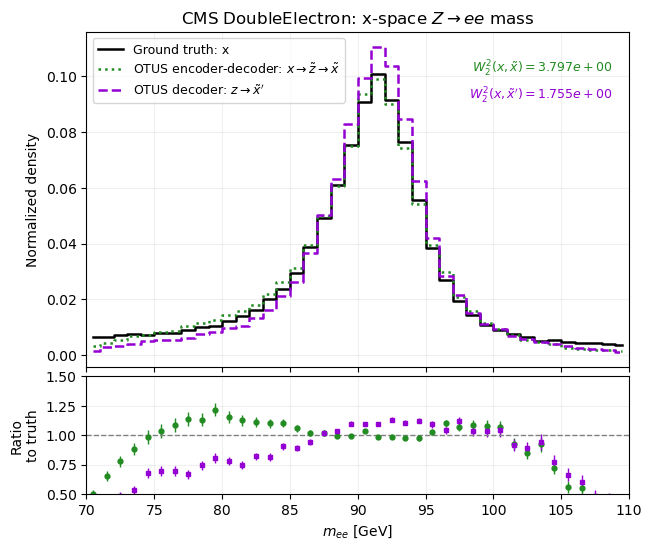

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_xspace_mass_density_ratio.png
m(CMS x)       mean/std: 90.16021 6.589292
m(x->z->x)    mean/std: 89.85514 7.1803985
m(z->x)       mean/std: 90.67542 6.082941


In [9]:
# ==============================================
# 7.1 Paper-style plot: x-space Z->ee mass
# ==============================================

m_x = inv_mass_ee(x_plot)
m_x_reco = inv_mass_ee(x_reco)
m_x_from_z = inv_mass_ee(x_from_z)

fig, axes, xmass_info = paper_ratio_plot_double(
    truth=m_x,
    pred1=m_x_reco,
    pred2=m_x_from_z,
    bins=MASS_BINS,
    xlabel=r"$m_{ee}$ [GeV]",
    title=r"CMS DoubleElectron: x-space $Z \rightarrow ee$ mass",
    filename="paperstyle_xspace_mass_density_ratio.png",
    xlim=(70, 110),
    ratio_ylim=(0.5, 1.5),
)

axes[0].axvline(MZ_REF, linestyle="--", linewidth=1.2, color="gray", label=fr"$m_Z={MZ_REF:.4f}$ GeV")
axes[0].legend(loc="best", fontsize=9)

print("m(CMS x)       mean/std:", m_x.mean(), m_x.std())
print("m(x->z->x)    mean/std:", m_x_reco.mean(), m_x_reco.std())
print("m(z->x)       mean/std:", m_x_from_z.mean(), m_x_from_z.std())


C:\Users\AhrixMarin\AppData\Local\Temp\ipykernel_9948\1380529030.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


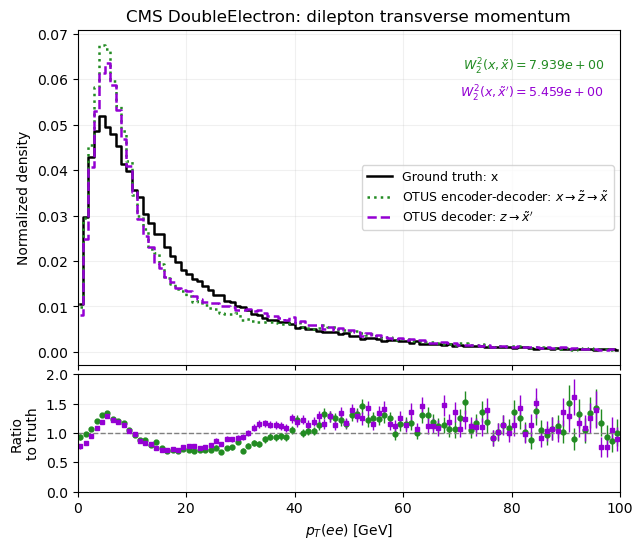

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_xspace_pt_density_ratio.png
pT KS x vs x->z->x: 0.0715125 / 2.50575e-178
pT KS x vs z->x:    0.042875 / 2.4829e-64


In [10]:
# ==========================================================
# 7.2 Paper-style plot: dilepton transverse momentum pT(ee)
# ==========================================================

pt_x = pt_ee(x_plot)
pt_x_reco = pt_ee(x_reco)
pt_x_from_z = pt_ee(x_from_z)

fig, axes, pt_info = paper_ratio_plot_double(
    truth=pt_x,
    pred1=pt_x_reco,
    pred2=pt_x_from_z,
    bins=PT_BINS,
    xlabel=r"$p_T(ee)$ [GeV]",
    title=r"CMS DoubleElectron: dilepton transverse momentum",
    filename="paperstyle_xspace_pt_density_ratio.png",
    xlim=(0, 100),
    ratio_ylim=(0.0, 2.0),
)

ks_pt_reco, p_pt_reco = maybe_ks(pt_x, pt_x_reco)
ks_pt_zx, p_pt_zx = maybe_ks(pt_x, pt_x_from_z)
print(f"pT KS x vs x->z->x: {ks_pt_reco:.6g} / {p_pt_reco:.6g}")
print(f"pT KS x vs z->x:    {ks_pt_zx:.6g} / {p_pt_zx:.6g}")


C:\Users\AhrixMarin\AppData\Local\Temp\ipykernel_9948\1380529030.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


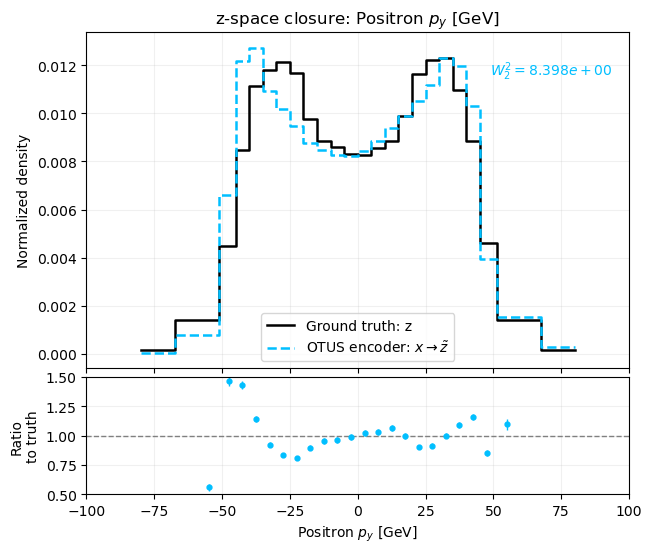

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_zspace_pos_py_ratio.png


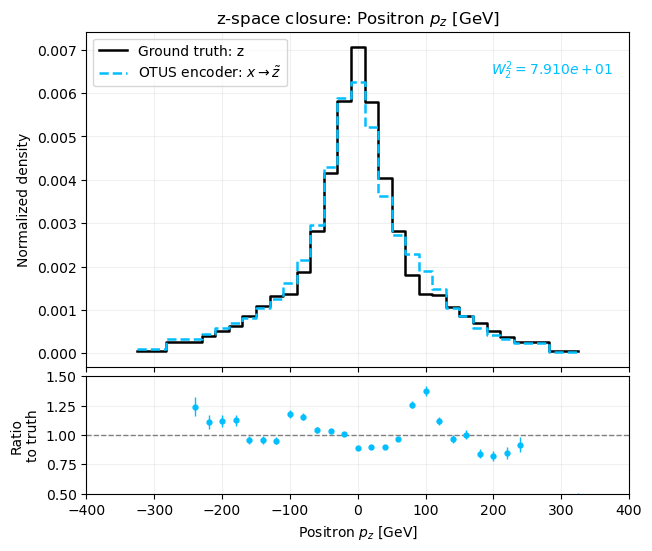

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_zspace_pos_pz_ratio.png


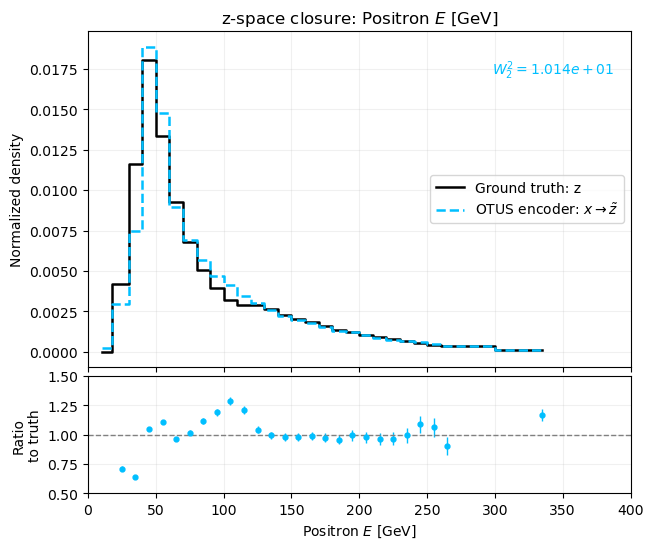

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_zspace_pos_E_ratio.png


In [11]:
# =====================================================
# 7.3 Paper-style z-space principal-axis component plots
# =====================================================

# Same principal-axis choices as the ppzee reference: positron py, pz, and E.
binsY = np.array([-100, -60] + [-50 + 5*i for i in range(20 + 1)] + [60, 100], dtype=float)
binsZ = np.array([-400] + [-250 + 20*i for i in range(25 + 1)] + [400], dtype=float)
binsE = np.array([0] + [20 + 10*i for i in range(25 + 1)] + [400], dtype=float)

principal_specs_z = [
    (5, binsY, r"Positron $p_y$ [GeV]", (-100, 100), (0.5, 1.5), "paperstyle_zspace_pos_py_ratio.png"),
    (6, binsZ, r"Positron $p_z$ [GeV]", (-400, 400), (0.5, 1.5), "paperstyle_zspace_pos_pz_ratio.png"),
    (7, binsE, r"Positron $E$ [GeV]", (0, 400), (0.5, 1.5), "paperstyle_zspace_pos_E_ratio.png"),
]

for idx, bins, xlabel, xlim, rylim, fname in principal_specs_z:
    paper_ratio_plot_single(
        truth=z_plot[:, idx],
        pred=z_encoded[:, idx],
        bins=bins,
        xlabel=xlabel,
        title=fr"z-space closure: {xlabel}",
        filename=fname,
        xlim=xlim,
        ratio_ylim=rylim,
    )


C:\Users\AhrixMarin\AppData\Local\Temp\ipykernel_9948\1380529030.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


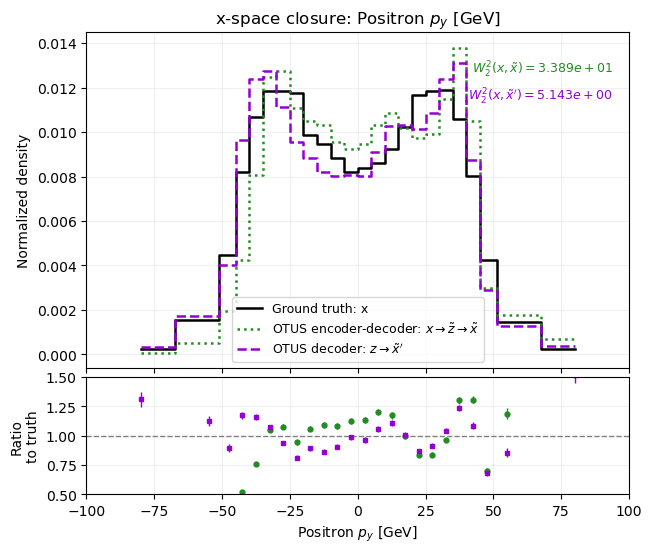

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_xspace_pos_py_ratio.png


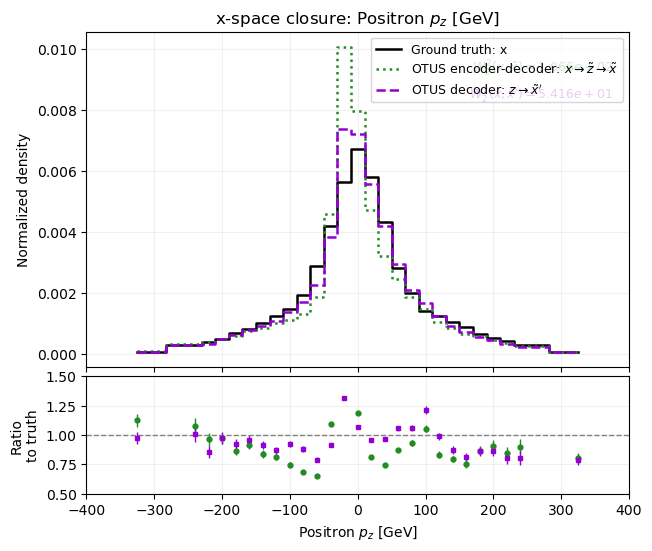

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_xspace_pos_pz_ratio.png


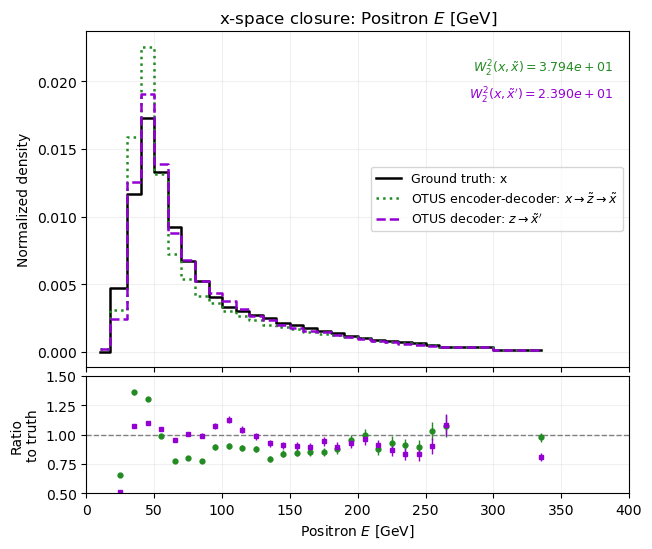

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_xspace_pos_E_ratio.png


In [12]:
# =====================================================
# 7.4 Paper-style x-space principal-axis component plots
# =====================================================

principal_specs_x = [
    (5, binsY, r"Positron $p_y$ [GeV]", (-100, 100), (0.5, 1.5), "paperstyle_xspace_pos_py_ratio.png"),
    (6, binsZ, r"Positron $p_z$ [GeV]", (-400, 400), (0.5, 1.5), "paperstyle_xspace_pos_pz_ratio.png"),
    (7, binsE, r"Positron $E$ [GeV]", (0, 400), (0.5, 1.5), "paperstyle_xspace_pos_E_ratio.png"),
]

for idx, bins, xlabel, xlim, rylim, fname in principal_specs_x:
    paper_ratio_plot_double(
        truth=x_plot[:, idx],
        pred1=x_reco[:, idx],
        pred2=x_from_z[:, idx],
        bins=bins,
        xlabel=xlabel,
        title=fr"x-space closure: {xlabel}",
        filename=fname,
        xlim=xlim,
        ratio_ylim=rylim,
    )


C:\Users\AhrixMarin\AppData\Local\Temp\ipykernel_9948\1380529030.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


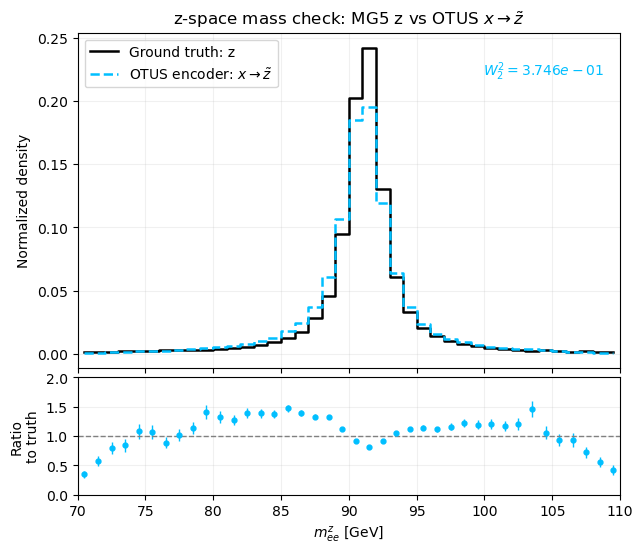

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\paperstyle_zspace_mass_density_ratio.png
m_mg5 mean/std: 91.0734 / 4.01991
m_x_to_z mean/std: 90.8841 / 4.4024
mass KS statistic/pvalue: 0.06105 / 4.82819e-130


In [13]:
# ==============================================
# 7.5 Paper-style plot: z-space invariant mass
# ==============================================

m_z_prior = inv_mass_ee(z_plot)
m_x_to_z = inv_mass_ee(z_encoded)

fig, axes, zmass_info = paper_ratio_plot_single(
    truth=m_z_prior,
    pred=m_x_to_z,
    bins=MASS_BINS,
    xlabel=r"$m_{ee}^{z}$ [GeV]",
    title=r"z-space mass check: MG5 z vs OTUS $x \rightarrow \tilde{z}$",
    filename="paperstyle_zspace_mass_density_ratio.png",
    xlim=(70, 110),
    ratio_ylim=(0.0, 2.0),
)
axes[0].axvline(MZ_REF, linestyle="--", linewidth=1.2, color="gray", label=fr"$m_Z={MZ_REF:.4f}$ GeV")
axes[0].legend(loc="best", fontsize=9)

ks_mass, p_mass = maybe_ks(m_z_prior, m_x_to_z)
print(f"m_mg5 mean/std: {m_z_prior.mean():.6g} / {m_z_prior.std():.6g}")
print(f"m_x_to_z mean/std: {m_x_to_z.mean():.6g} / {m_x_to_z.std():.6g}")
print(f"mass KS statistic/pvalue: {ks_mass:.6g} / {p_mass:.6g}")


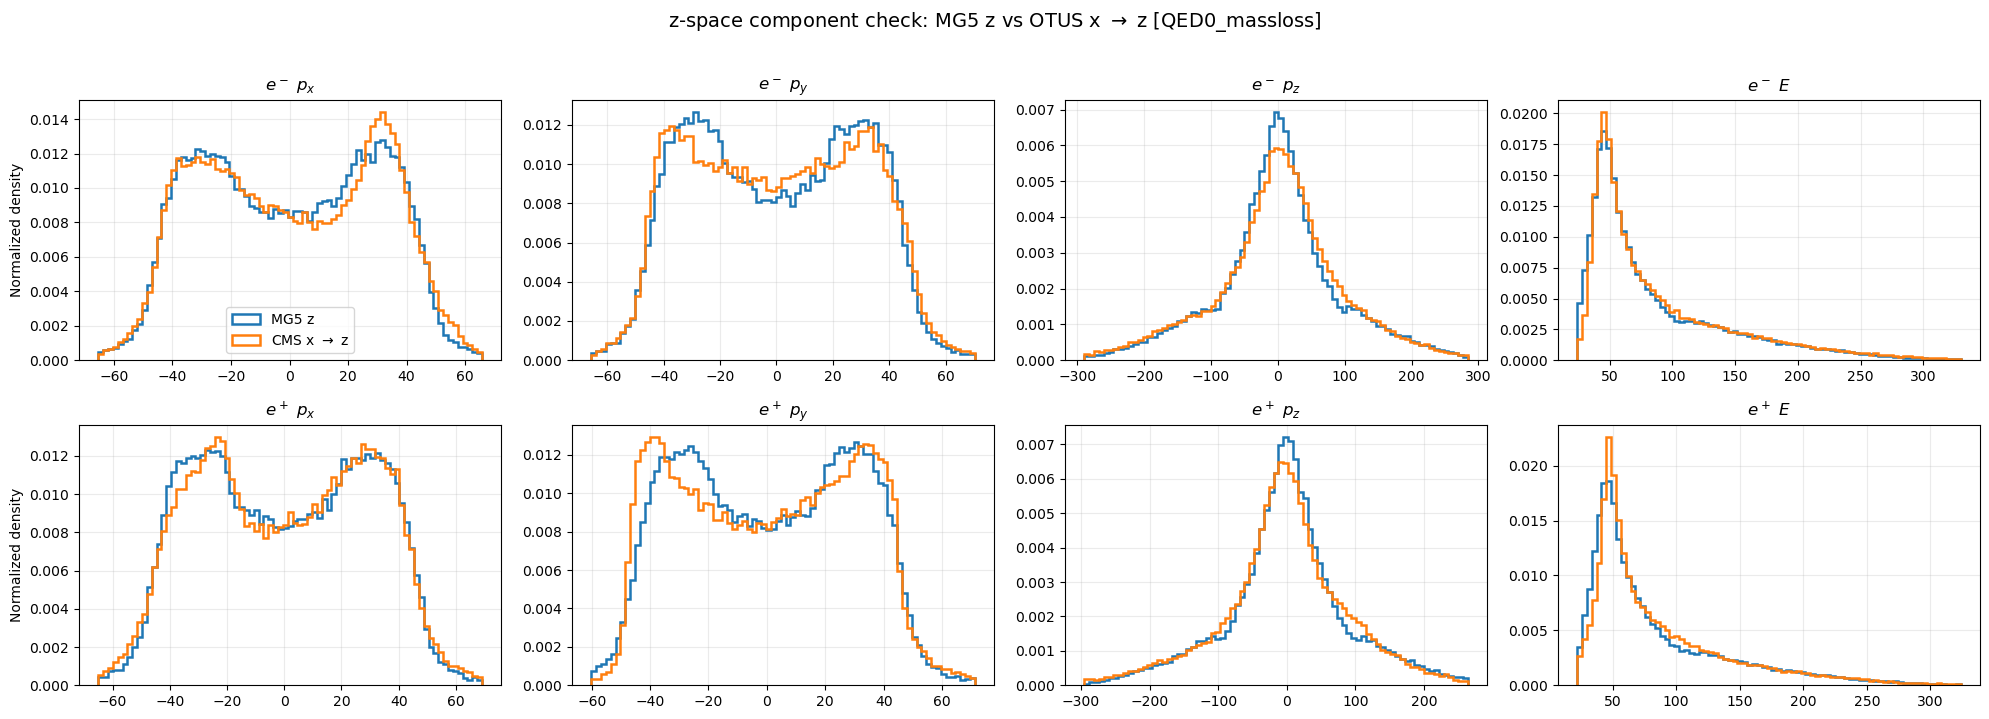

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\all8_zspace_components_density.png


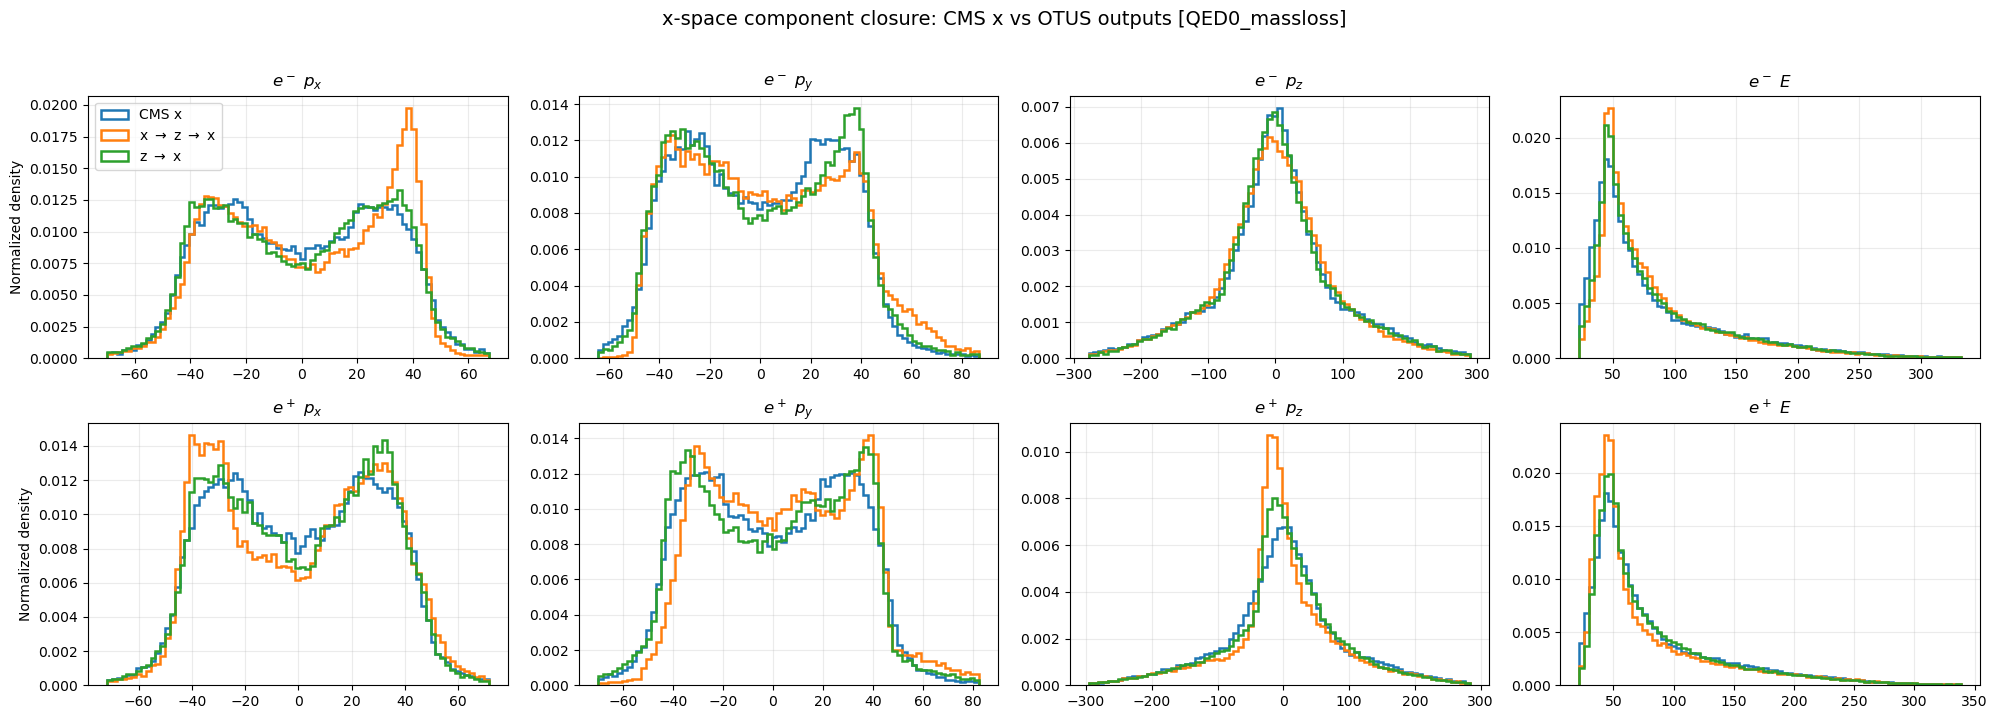

Saved: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\plots\QED0_massloss\all8_xspace_components_density.png


In [14]:
# ======================================================
# 7.6 Optional quick overview: all 8 components, density
# ======================================================

component_titles = [
    r"$e^-\ p_x$", r"$e^-\ p_y$", r"$e^-\ p_z$", r"$e^-\ E$",
    r"$e^+\ p_x$", r"$e^+\ p_y$", r"$e^+\ p_z$", r"$e^+\ E$",
]

# z-space components
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
fig.suptitle(f"z-space component check: MG5 z vs OTUS x $\\rightarrow$ z [{TAG}]", y=1.02, fontsize=14)
for j, ax in enumerate(axes.ravel()):
    all_j = np.concatenate([z_plot[:, j], z_encoded[:, j]])
    lo, hi = np.nanpercentile(all_j, [0.5, 99.5])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(all_j), np.nanmax(all_j)
    bins = np.linspace(lo, hi, COMPONENT_BINS_Z)
    ax.hist(z_plot[:, j], bins=bins, density=True, histtype="step", linewidth=1.8, label="MG5 z")
    ax.hist(z_encoded[:, j], bins=bins, density=True, histtype="step", linewidth=1.8, label=r"CMS x $\rightarrow$ z")
    ax.set_title(component_titles[j])
    ax.grid(alpha=0.25)
    if j in [0, 4]:
        ax.set_ylabel("Normalized density")
    if j == 0:
        ax.legend()
plt.tight_layout()
path = OUTDIR / "all8_zspace_components_density.png"
plt.savefig(path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", path)

# x-space components
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
fig.suptitle(f"x-space component closure: CMS x vs OTUS outputs [{TAG}]", y=1.02, fontsize=14)
for j, ax in enumerate(axes.ravel()):
    all_j = np.concatenate([x_plot[:, j], x_reco[:, j], x_from_z[:, j]])
    lo, hi = np.nanpercentile(all_j, [0.5, 99.5])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(all_j), np.nanmax(all_j)
    bins = np.linspace(lo, hi, COMPONENT_BINS_X)
    ax.hist(x_plot[:, j], bins=bins, density=True, histtype="step", linewidth=1.8, label="CMS x")
    ax.hist(x_reco[:, j], bins=bins, density=True, histtype="step", linewidth=1.8, label=r"x $\rightarrow$ z $\rightarrow$ x")
    ax.hist(x_from_z[:, j], bins=bins, density=True, histtype="step", linewidth=1.8, label=r"z $\rightarrow$ x")
    ax.set_title(component_titles[j])
    ax.grid(alpha=0.25)
    if j in [0, 4]:
        ax.set_ylabel("Normalized density")
    if j == 0:
        ax.legend()
plt.tight_layout()
path = OUTDIR / "all8_xspace_components_density.png"
plt.savefig(path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", path)


In [15]:
# =================================
# 8. Save numerical summary
# =================================

summary_lines = []
summary_lines.append(f"TAG: {TAG}")
summary_lines.append(f"NORMALIZE_DENSITY: {NORMALIZE_DENSITY}")
summary_lines.append(f"MODEL_PATH: {MODEL_PATH}")
summary_lines.append(f"CMS_X_FILE: {CMS_X_FILE}")
summary_lines.append(f"MG5_Z_FILE: {MG5_Z_FILE}")
summary_lines.append(f"z_mg5 shape: {z_plot.shape}")
summary_lines.append(f"z_encoded shape: {z_encoded.shape}")
summary_lines.append(f"x_plot shape: {x_plot.shape}")
summary_lines.append(f"x_reco shape: {x_reco.shape}")
summary_lines.append(f"x_from_z shape: {x_from_z.shape}")
summary_lines.append(f"m_mg5 mean/std: {m_z_prior.mean():.6g} / {m_z_prior.std():.6g}")
summary_lines.append(f"m_x_to_z mean/std: {m_x_to_z.mean():.6g} / {m_x_to_z.std():.6g}")
summary_lines.append(f"mass KS statistic/pvalue: {ks_mass:.6g} / {p_mass:.6g}")
summary_lines.append(f"pT KS x vs x->z->x: {ks_pt_reco:.6g} / {p_pt_reco:.6g}")
summary_lines.append(f"pT KS x vs z->x: {ks_pt_zx:.6g} / {p_pt_zx:.6g}")

for j in range(8):
    ks_j, p_j = maybe_ks(z_plot[:, j], z_encoded[:, j])
    summary_lines.append(f"z dim {j:02d} KS statistic/pvalue: {ks_j:.6g} / {p_j:.6g}")

summary_path = OUTDIR / f"paperstyle_summary_{TAG}.txt"
summary_path.write_text("\n".join(summary_lines))
print(summary_path.read_text())
print("Saved:", summary_path)

arrays_path = OUTDIR / f"paperstyle_loaded_model_outputs_{TAG}.npz"
np.savez_compressed(
    arrays_path,
    x_plot=x_plot,
    z_plot=z_plot,
    z_encoded=z_encoded,
    x_reco=x_reco,
    x_from_z=x_from_z,
    m_z_prior=m_z_prior,
    m_x_to_z=m_x_to_z,
    m_x=m_x,
    m_x_reco=m_x_reco,
    m_x_from_z=m_x_from_z,
    pt_x=pt_x,
    pt_x_reco=pt_x_reco,
    pt_x_from_z=pt_x_from_z,
)
print("Saved:", arrays_path)


TAG: QED0_massloss
NORMALIZE_DENSITY: True
MODEL_PATH: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v1_fullproduction\model_full.pt
CMS_X_FILE: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root
MG5_Z_FILE: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron\cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5
z_mg5 shape: (80000, 8)
z_encoded shape: (80000, 8)
x_plot shape: (80000, 8)
x_reco shape: (80000, 8)
x_from_z shape: (80000, 8)
m_mg5 mean/std: 91.0734 / 4.01991
m_x_to_z mean/std: 90.8841 / 4.4024
mass KS statistic/pvalue: 0.06105 / 4.82819e-130
pT KS x vs x->z->x: 0.0715125 / 2.50575e-178
pT KS x vs z->x: 0.042875 / 2.4829e-64
z dim 00 KS statistic/pvalue: 0.0206875 / 2.65714e-15
z dim 01 KS statistic/pvalue: 0.0145375 / 8.99189e-08
z dim 02 KS statistic/pvalue: 0.036175 / 6.47275e-46
z dim 03 KS statistic/pvalue: 0.0396125 / 5.66202e-55
z dim 04 KS statistic/pva

## Notes

This notebook follows the paper-plot logic from the reference notebook, but with the correct CMS input source:

- `CMS x` comes from `Run2012B_DoubleElectron.root`;
- `MG5 z` comes from `cms_dyee_mg5_8tev_fiducial_70_110.hdf5`;
- invariant mass and principal-axis plots have lower ratio-to-truth panels;
- top panels use normalized density by default via `NORMALIZE_DENSITY = True`;
- selected principal-axis plots follow the reference choice: positron `p_y`, `p_z`, and `E`.

If the ROOT loader fails, run:

```python
list_root_trees_and_branches(CMS_ROOT_FILE)
```

Then manually set the branch names in the settings cell:

```python
CMS_TREE_NAME = "..."
CMS_ELECTRON_PT_BRANCH = "..."
CMS_ELECTRON_ETA_BRANCH = "..."
CMS_ELECTRON_PHI_BRANCH = "..."
CMS_ELECTRON_E_BRANCH = "..."
CMS_ELECTRON_CHARGE_BRANCH = "..."
```
